<a href="https://colab.research.google.com/github/purkutis/Samuel_INFO4670_SPRING2026/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [1]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> I think false negative is more costly in a real spam filter compared to a false positive because if the model spams the email that really matters it may directly affect the user and the person who is using such filters.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> Since a False Positive is so costly, I believe that Precision should be our primary metric of concern.


**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> If a model always predicts "ham," it will be correct 86.6% of the time. The number is still misleading because, it has nothing mentioned about recall.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [2]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


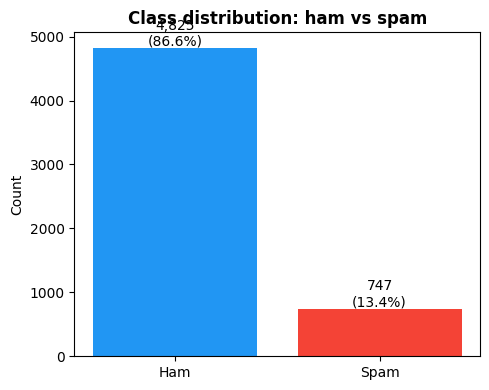

In [3]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [4]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


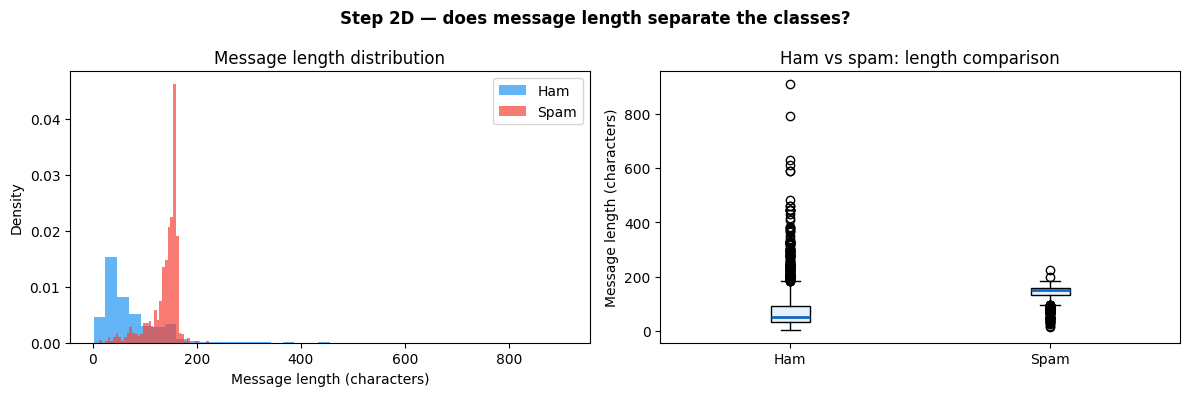

In [5]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [6]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [10]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: add your first feature here ---
    d['has_url'] = msg.str.contains(r'http|www\.', regex=True).astype(int)

    # --- Feature 6: add your second feature here ---
    d['is_cta'] = msg.str.contains(r'\b(txt|text|reply|stop)\b', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_url                14.3%    0.0%  +14.3%
is_cta                 44.6%    3.2%  +41.4%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


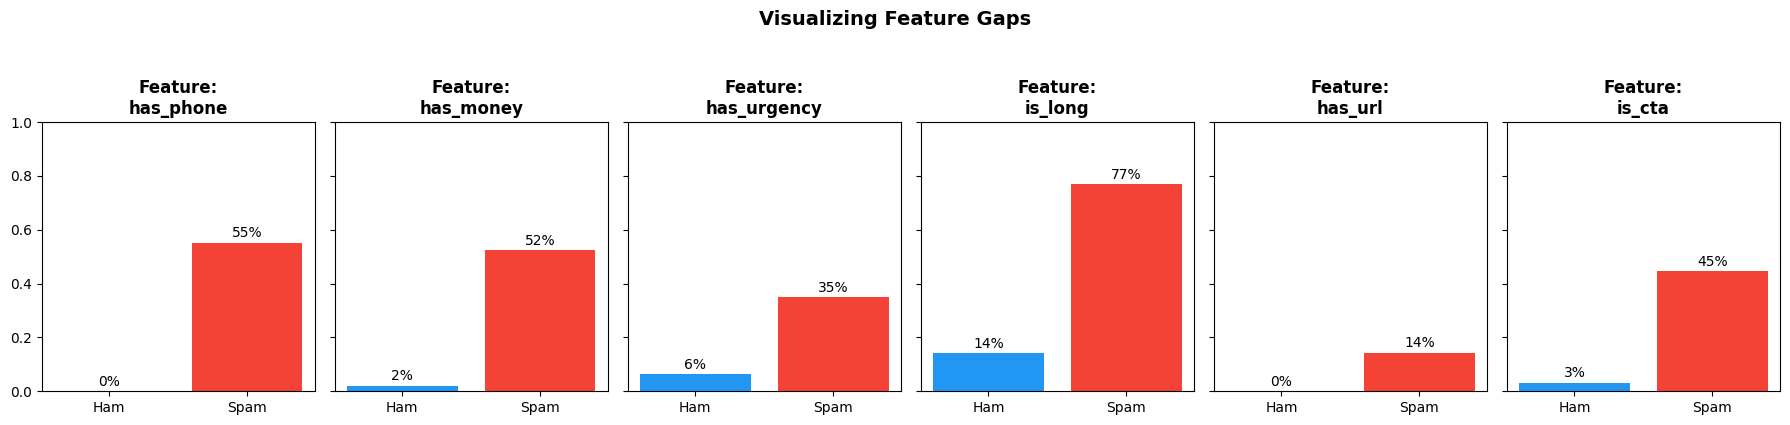

In [21]:
# Create a grid
n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(n_features * 3, 4), sharey=True)

#create a mini bar chart
for i, feat in enumerate(feature_cols):
    # Calculate rates
    spam_rate = df[df['spam'] == 1][feat].mean()
    ham_rate = df[df['spam'] == 0][feat].mean()

    # Plot bars
    axes[i].bar(['Ham', 'Spam'], [ham_rate, spam_rate], color=['#2196F3', '#F44336'])
    axes[i].set_title(f'Feature:\n{feat}', fontweight='bold')
    axes[i].set_ylim(0, 1) # Set Y-axis to 100%

    # Add percentage labels on top of bars
    axes[i].text(0, ham_rate + 0.02, f'{ham_rate:.0%}', ha='center')
    axes[i].text(1, spam_rate + 0.02, f'{spam_rate:.0%}', ha='center')

plt.suptitle('Visualizing Feature Gaps', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — has_url:
> This feature is used to detect strings such as http or www. I am using this feature because personal conversation rarely do have web links.

*Feature 2 — is_cta:*
> This is one of the features about which I learnt lately. I found out that spam emails have a automate call to action strategy to enhance user engagement.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> In the chart, is_long or has_phone has the largest gap. The Decision tree selects its root as the node because it reduces the uncertainity in the dataset with a single question and effective seperation.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> I think a spam message that isn't long, doesn have numbers and url will be good to enough to not be catched by the filter.  Since our feature rely on "trigger words", a short casual sounding spam message can pass itself from the filter.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [22]:
# Write your code here
X = df[feature_cols].values
y = df['spam'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> I learnt this the hardway in the previous assignment where I had forgot to stratify the model. Stratifying a model ensures that it has same percentage of spam as the original dataset has in the test and training dataset to make the randomnes similar to the original dataset.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> I think k-fold will be better when using smaller dataset because smaller dataset with 75/25 representation may not be practical and realistic.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 14


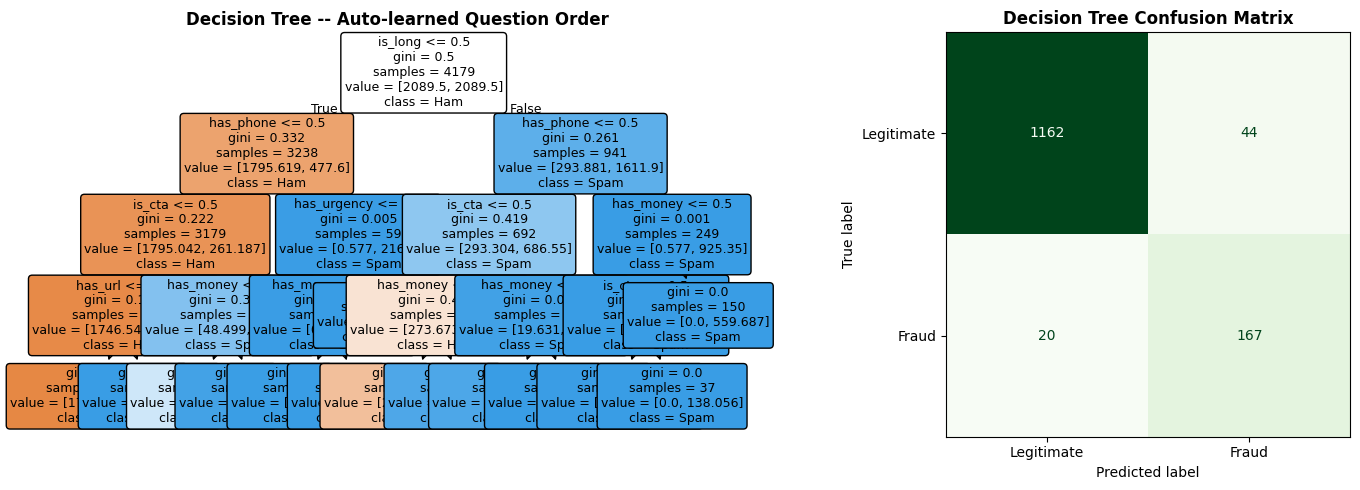


Text Rules:
|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- is_cta <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- is_cta >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- is_cta <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- is_cta >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_p

In [23]:
# Write your code here
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"Number of leaves: {dt.get_n_leaves()}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_tree(dt, feature_names=feature_cols, class_names=['Ham','Spam'],
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title('Decision Tree -- Auto-learned Question Order', fontweight='bold')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=['Legitimate','Fraud']).plot(
                       ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Decision Tree Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nText Rules:')
print(export_text(dt, feature_names=feature_cols))


### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


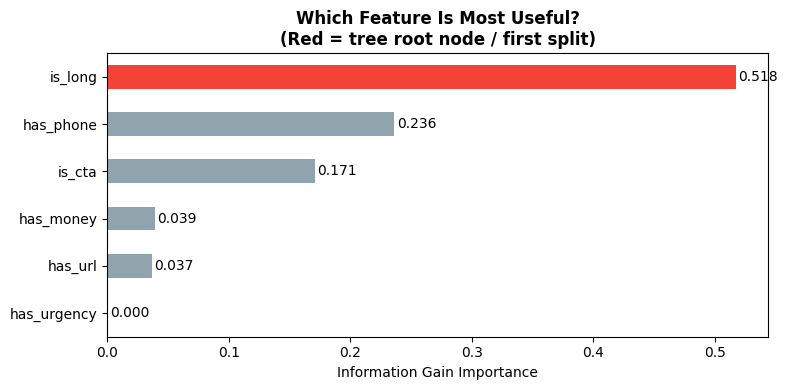


First question (root node): "is_long"
This feature has the highest Information Gain -- reduces uncertainty the most.


In [24]:
# Write your code here
# Which feature does the tree pick FIRST?
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#F44336' if v == importances.max() else '#90A4AE' for v in importances]
importances.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_xlabel('Information Gain Importance')
ax.set_title('Which Feature Is Most Useful?\n(Red = tree root node / first split)', fontweight='bold')
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()
print(f'\nFirst question (root node): "{importances.idxmax()}"')
print('This feature has the highest Information Gain -- reduces uncertainty the most.')

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


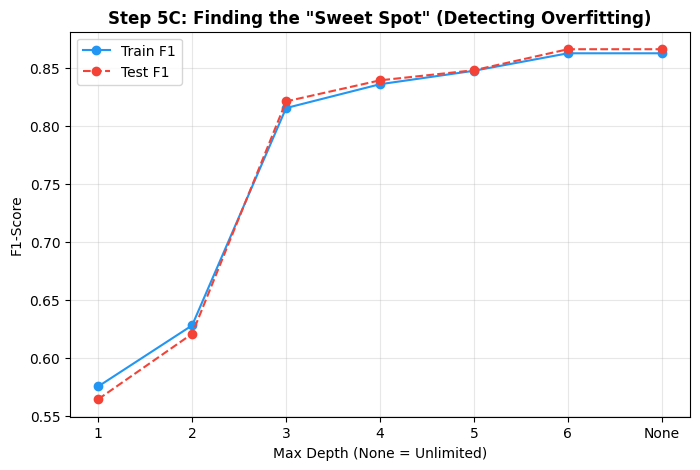

Best Test F1 is at depth: 6


In [25]:
# Loop over different depths to see where overfitting begins
depths = [1, 2, 3, 4, 5, 6, None]
train_f1_scores = []
test_f1_scores = []

for d in depths:
    # Train model with current depth
    model = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    # Record F1 scores
    train_f1_scores.append(f1_score(y_train, model.predict(X_train)))
    test_f1_scores.append(f1_score(y_test, model.predict(X_test)))

# Plotting the results
plt.figure(figsize=(8, 5))

x_labels = [str(d) for d in depths]

plt.plot(x_labels, train_f1_scores, marker='o', label='Train F1', color='#2196F3')
plt.plot(x_labels, test_f1_scores, marker='o', label='Test F1', color='#F44336', linestyle='--')

plt.xlabel('Max Depth (None = Unlimited)')
plt.ylabel('F1-Score')
plt.title('Step 5C: Finding the "Sweet Spot" (Detecting Overfitting)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best Test F1 is at depth: {depths[np.argmax(test_f1_scores)]}")


### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [26]:
# Write your code here
nb = BernoulliNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print('sklearn Naive Bayes on test set:')
print(f'  Precision : {precision_score(y_test, y_pred_nb):.1%}')
print(f'  Recall    : {recall_score(y_test, y_pred_nb):.1%}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_nb):.1%}')

sklearn Naive Bayes on test set:
  Precision : 87.1%
  Recall    : 86.6%
  F1-Score  : 86.9%


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


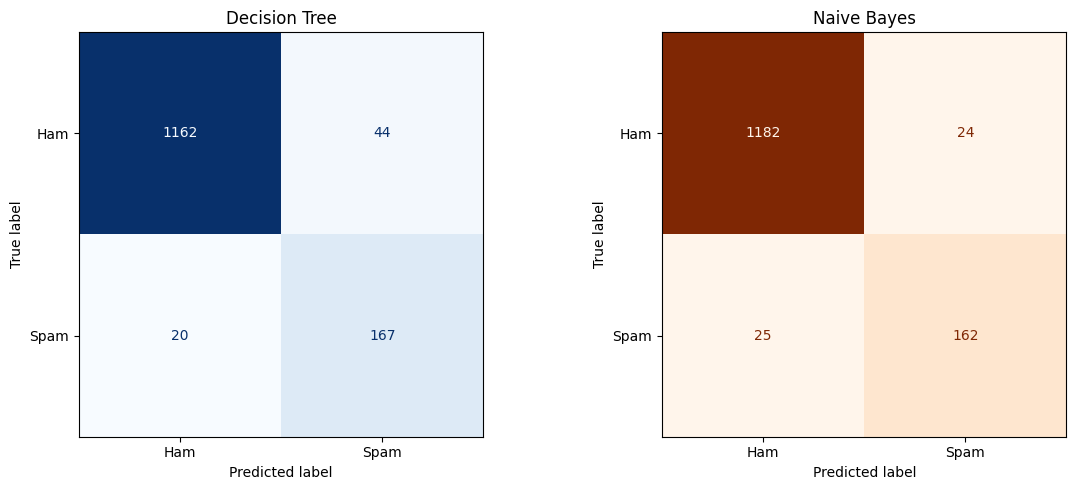

Decision Tree:
  True Positives (Caught Spam): 167
  False Positives (Blocked Ham): 44
  False Negatives (Missed Spam): 20
  True Negatives (Allowed Ham):  1162

Naive Bayes:
  True Positives (Caught Spam): 162
  False Positives (Blocked Ham): 24
  False Negatives (Missed Spam): 25
  True Negatives (Allowed Ham):  1182



In [28]:
# Write your code here
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, display_labels=['Ham', 'Spam'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Decision Tree')

# Plot Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb, display_labels=['Ham', 'Spam'],
    cmap='Oranges', ax=axes[1], colorbar=False
)
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()


for name, y_pred in [("Decision Tree", y_pred_dt), ("Naive Bayes", y_pred_nb)]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"{name}:")
    print(f"  True Positives (Caught Spam): {tp}")
    print(f"  False Positives (Blocked Ham): {fp}")
    print(f"  False Negatives (Missed Spam): {fn}")
    print(f"  True Negatives (Allowed Ham):  {tn}\n")

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


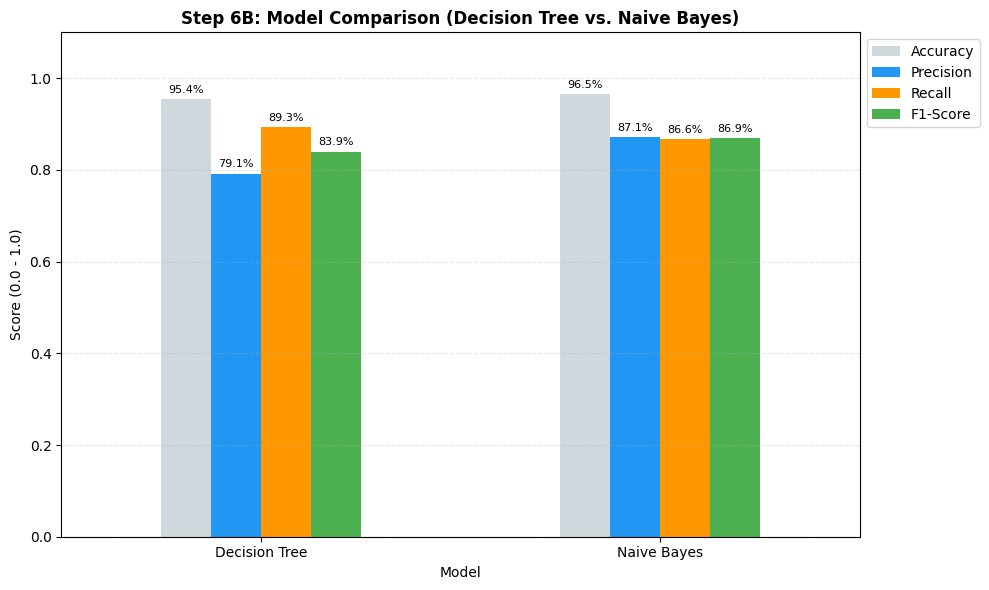

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,95.4%,79.1%,89.3%,83.9%
Naive Bayes,96.5%,87.1%,86.6%,86.9%


In [29]:
# Write your code here
models = {
    "Decision Tree": y_pred_dt,
    "Naive Bayes": y_pred_nb
}

results = []

for name, y_pred in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# 2. Create the DataFrame
df_results = pd.DataFrame(results).set_index('Model')

# 3. Plot grouped bar chart comparing all four metrics
ax = df_results.plot(kind='bar', figsize=(10, 6), rot=0,
                     color=['#CFD8DC', '#2196F3', '#FF9800', '#4CAF50'])

plt.title('Step 6B: Model Comparison (Decision Tree vs. Naive Bayes)', fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add text labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7),
                textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

# Display the formatted table
display(df_results.style.format("{:.1%}"))

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [30]:
# Write your code here
# 1. Setup the Cross-Validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Run cross-validation for both models using F1-score
dt_cv_scores = cross_val_score(dt, X, y, cv=skf, scoring='f1')
nb_cv_scores = cross_val_score(nb, X, y, cv=skf, scoring='f1')

# 3. Print the results
print("Cross-Validation Results (Average F1-Score):")
print(f"  Decision Tree : {dt_cv_scores.mean():.1%} (+/- {dt_cv_scores.std():.1%})")
print(f"  Naive Bayes   : {nb_cv_scores.mean():.1%} (+/- {nb_cv_scores.std():.1%})")

# Comparison Check
if nb_cv_scores.mean() > dt_cv_scores.mean():
    print("\nConfirmation: Naive Bayes maintains a higher F1-score across all folds.")
else:
    print("\nConfirmation: Decision Tree performs more consistently across all folds.")

Cross-Validation Results (Average F1-Score):
  Decision Tree : 82.9% (+/- 3.2%)
  Naive Bayes   : 88.1% (+/- 1.5%)

Confirmation: Naive Bayes maintains a higher F1-score across all folds.


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
>167 spams were correctly caught.
20 spams slipped through.
44 legitimate messages were wrongly blocked.

*Naive Bayes:*
> 162 spams were correctly caught.
25 spams slipped throught.
24 legitimate messages were wrongly blocked.

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
>Naive Bayes wins on the metric of Precision. It achieved 87.1% precision compared to the Decision Tree's 79.1%, a lead of 8.0 percentage points. This means Naive Bayes is significantly better at avoiding False Positives and the cross validation confirms this.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
>I recommend deploying the Naive Bayes model for our SMS spam filter. My analysis shows that this model achieved a Precision of 87.1%, which is critical for a mobile carrier because it minimizes the number of legitimate customer messages that are accidentally blocked. While the model is highly precise, one weakness is its slightly lower Recall (86.6%) compared to the Decision Tree, meaning it allows a few more spam messages to reach the inbox. To improve this, we could implement a TF-IDF vectorizer in the future to capture specific "spammy" words that our current binary manual features might be missing.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> I think the two features that would likely fall is ofcourse is_cta and is_long feature because nowadays in emails there is a practice of having signatures and social networks to better connect. This can flag emails that are legitimate thus this feature would surely fail in the modern day spam filtering scenarios.

